In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

basedir = "../res0"

/tmp/ipykernel_1957828/3361696667.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


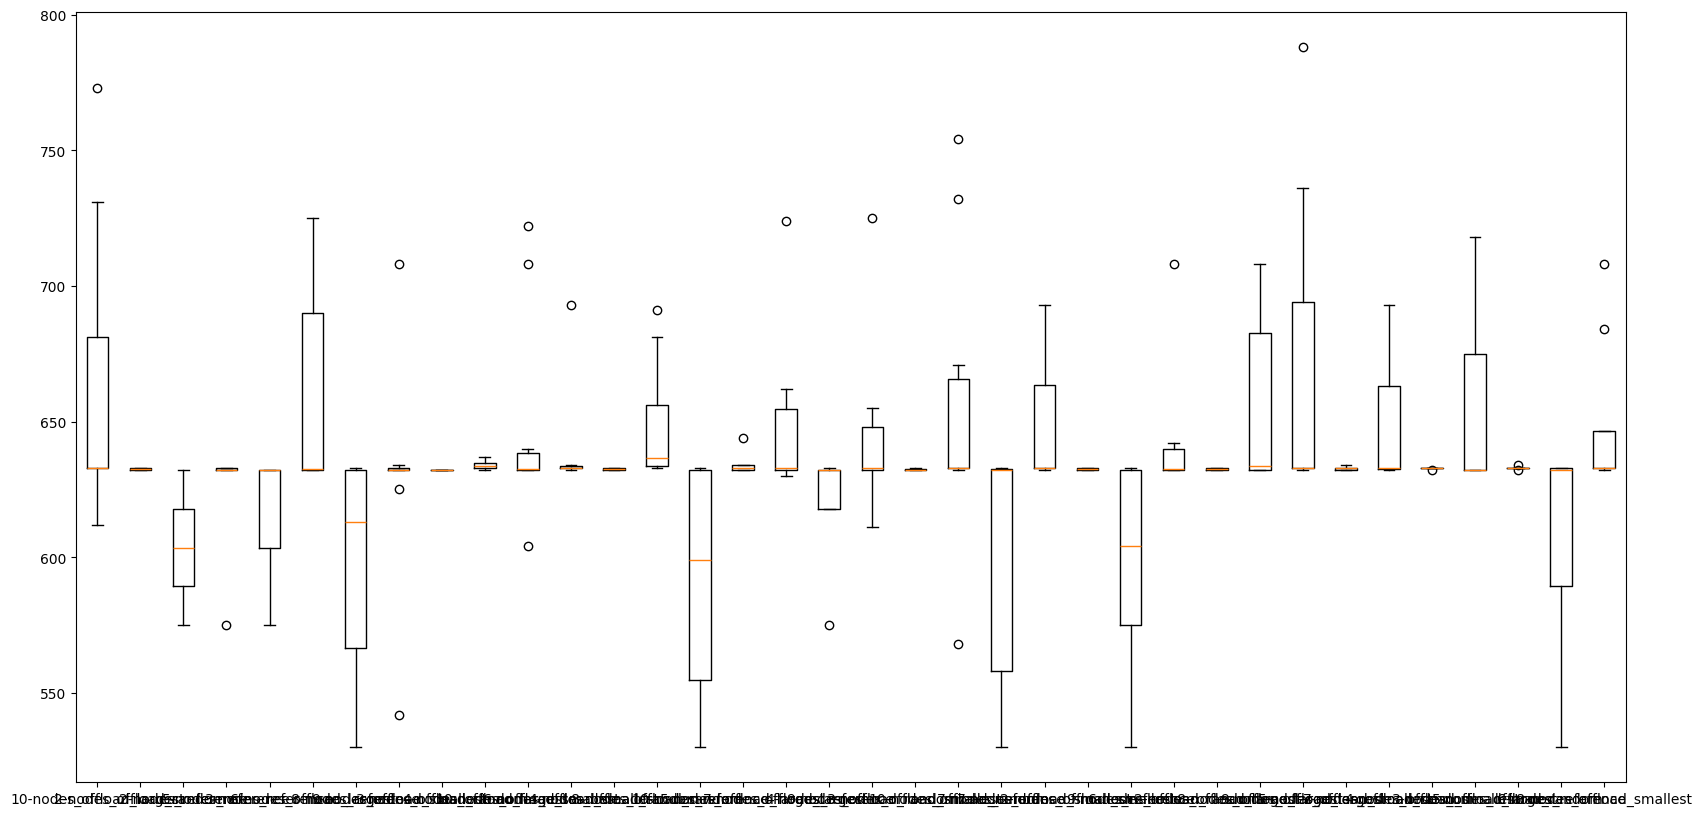

In [2]:
def plot_robot_average_operation_time(basedir):
    fig, ax1 = plt.subplots()
    labels = []
    data = []
    
    for dir in os.listdir(basedir):
        if not os.path.isdir(os.path.join(basedir, dir)):
            continue
        
        df = pd.read_csv(os.path.join(basedir, dir, 'simulation_stats.csv'))
        
        data.append(df.filter(like='operation_time').sum())
        labels.append(dir)
        
    ax1.boxplot(data)
    ax1.set_xticklabels(labels)
    fig.set_figheight(10)
    fig.set_figwidth(20)
    fig.show()
        
plot_robot_average_operation_time(basedir)
    

/tmp/ipykernel_1957828/3786977211.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend()
/tmp/ipykernel_1957828/3786977211.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


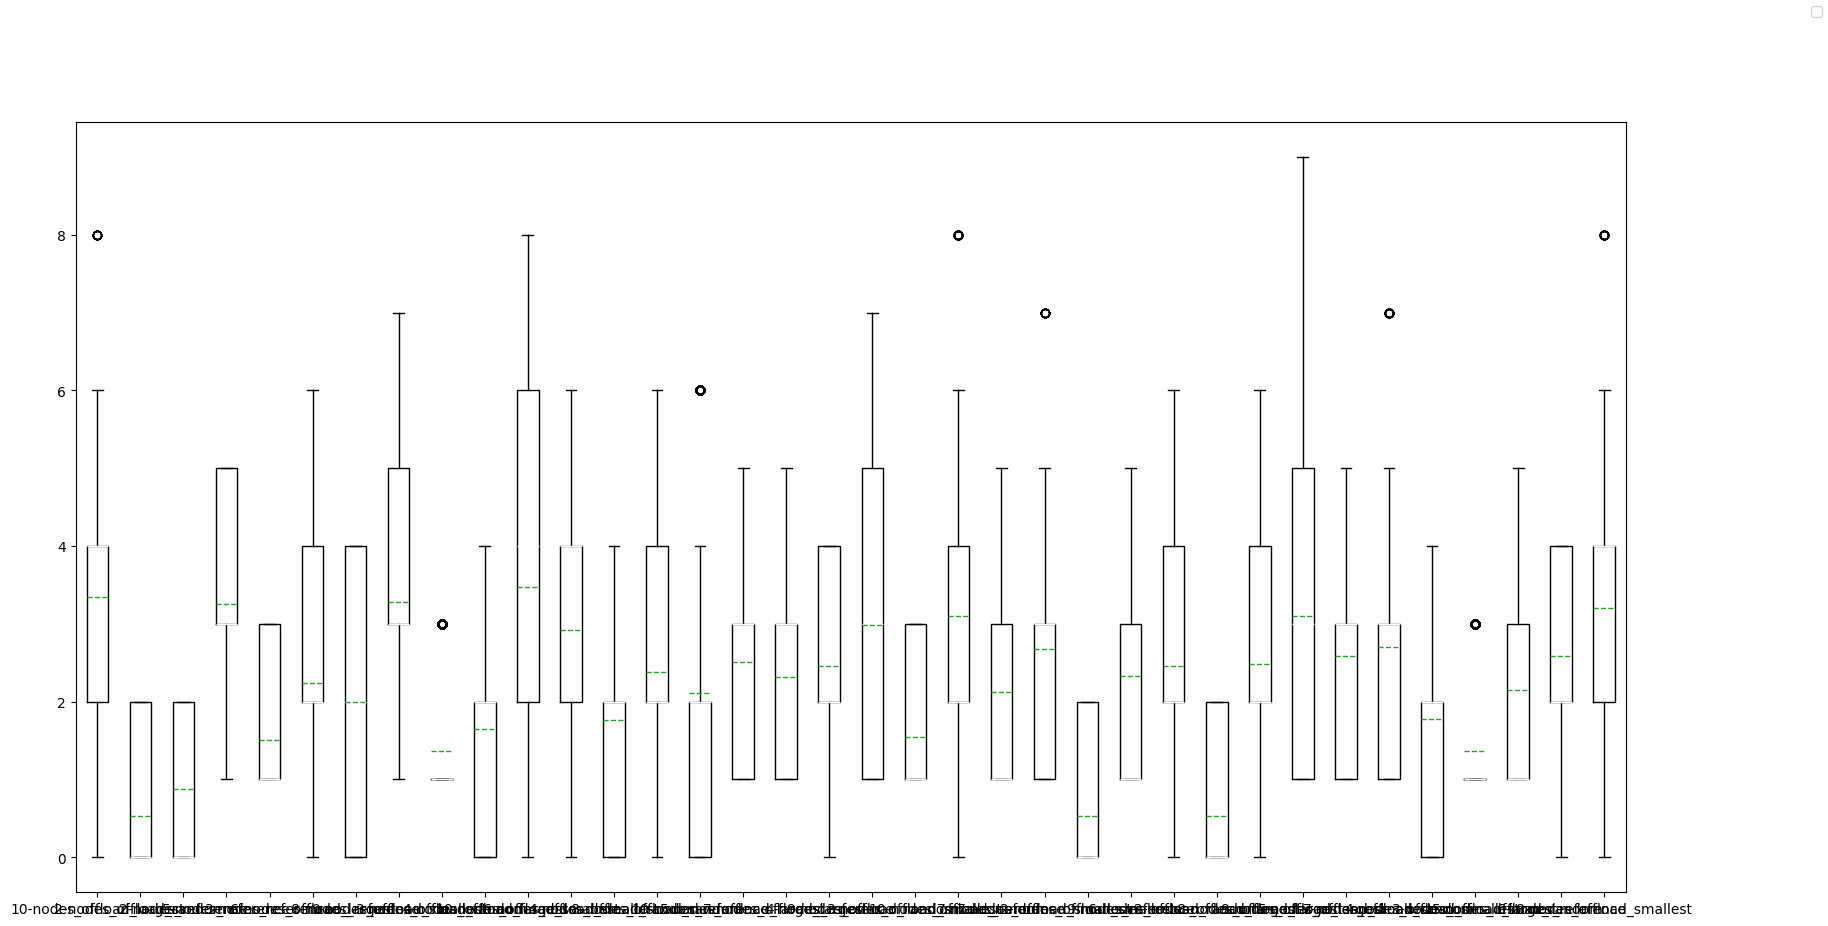

In [3]:
def plot_robot_status_diff(basedir):
    fig, ax2 = plt.subplots()
    data = []
    labels = []
    
    for dir in os.listdir(basedir):
        if not os.path.isdir(os.path.join(basedir, dir)):
            continue
        
        df = pd.read_csv(os.path.join(basedir, dir, 'robot_status.csv'))
        df["diff"] = abs(df["charging"] - df["operating"])
        
        # ax1.plot(df["epoch"], df["diff"], label=dir)
        data.append(df["diff"])
        labels.append(dir)
        
    ax2.boxplot(data, showmeans=True, meanline=True,
            medianprops=dict(color='white'))
    ax2.set_xticklabels(labels)
    fig.set_figheight(10)
    fig.set_figwidth(20)
    fig.legend()
    fig.show()
        
plot_robot_status_diff(basedir)
  

/tmp/ipykernel_1957828/2706923141.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


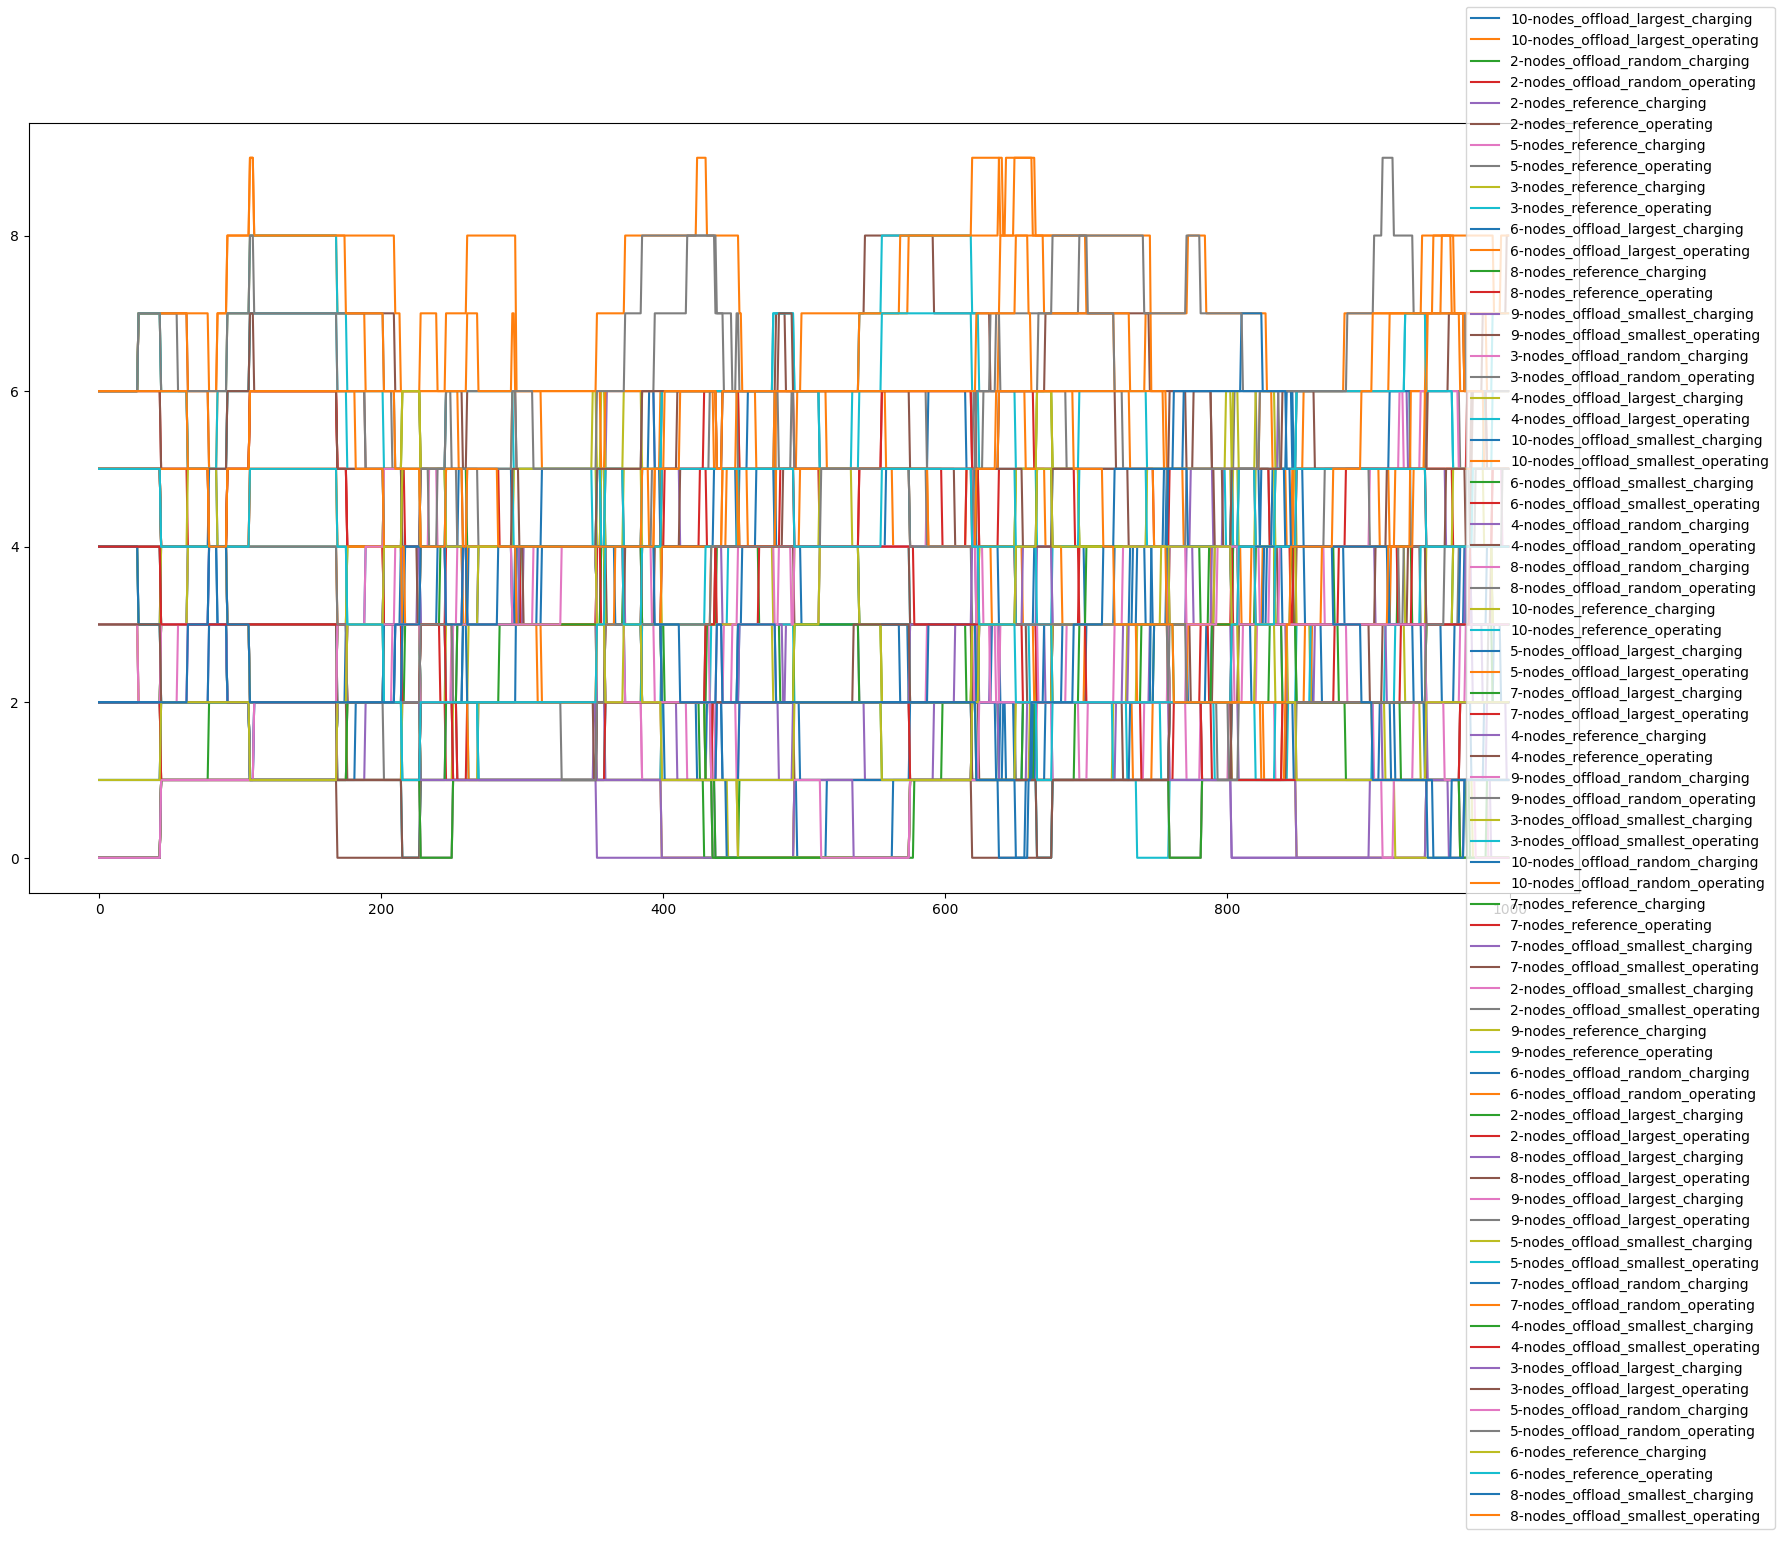

In [4]:
def plot_robot_status(basedir):
    fig, ax = plt.subplots()
    
    for dir in os.listdir(basedir):
        if not os.path.isdir(os.path.join(basedir, dir)):
            continue
        
        df = pd.read_csv(os.path.join(basedir, dir, 'robot_status.csv'))
        ax.plot(df["epoch"], df["charging"], label=dir+"_charging")
        ax.plot(df["epoch"], df["operating"], label=dir+"_operating")        
    
    fig.set_figheight(10)
    fig.set_figwidth(20)
    fig.legend()
    fig.show()
    
plot_robot_status(basedir)


/tmp/ipykernel_1957828/1103045323.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


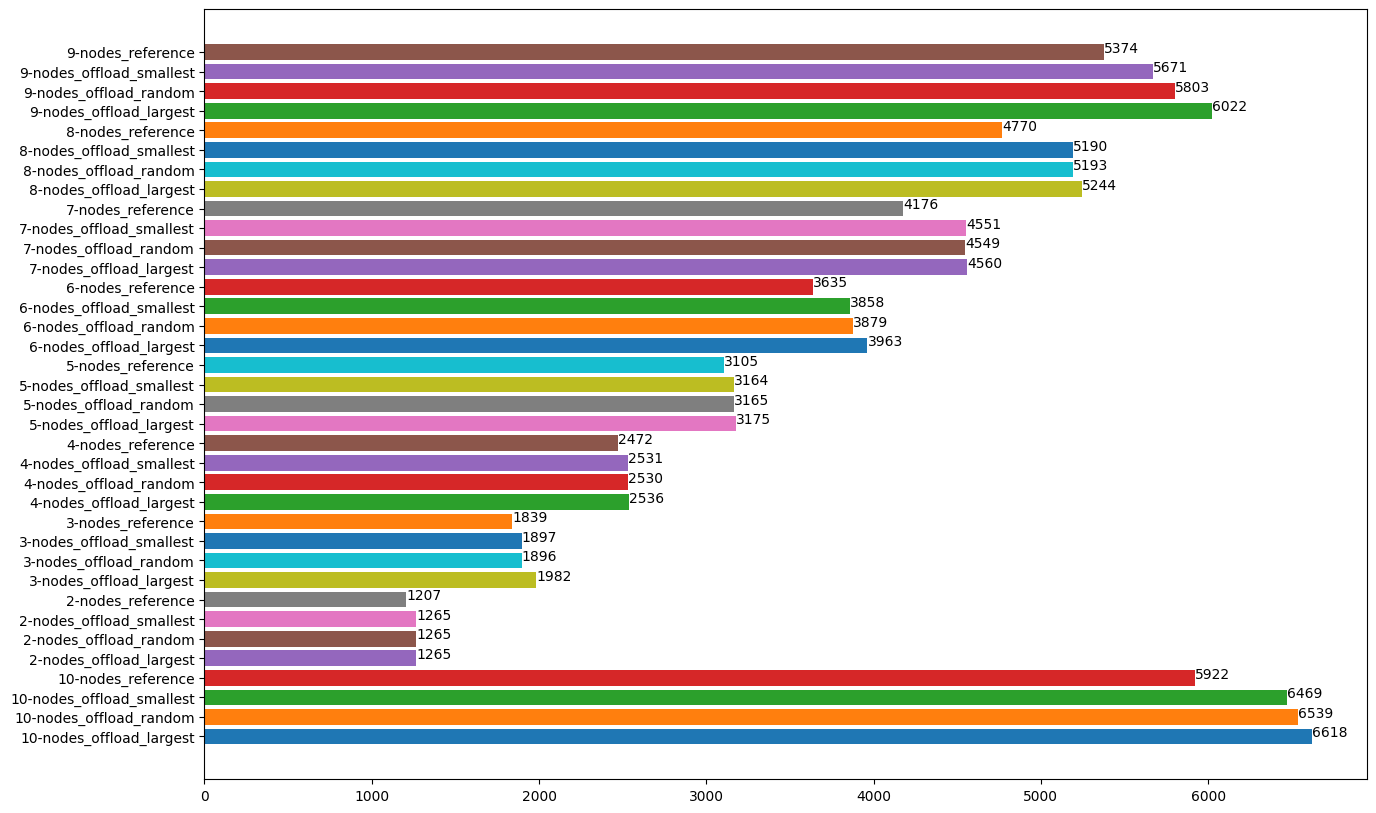

In [5]:
def plot_robot_operation_time(basedir):
    fig, ax = plt.subplots()
    
    for dir in sorted(os.listdir(basedir)):
        if not os.path.isdir(os.path.join(basedir, dir)):
            continue
        
        df = pd.read_csv(os.path.join(basedir, dir, 'simulation_stats.csv'))
        
        cum = df.filter(like='operation_time').sum().sum()
        
        ax.barh(dir, cum)
        ax.text(cum, dir, str(int(cum)))

    fig.set_figheight(10)
    fig.set_figwidth(15)
    #fig.legend()
    fig.show()
    
plot_robot_operation_time(basedir)


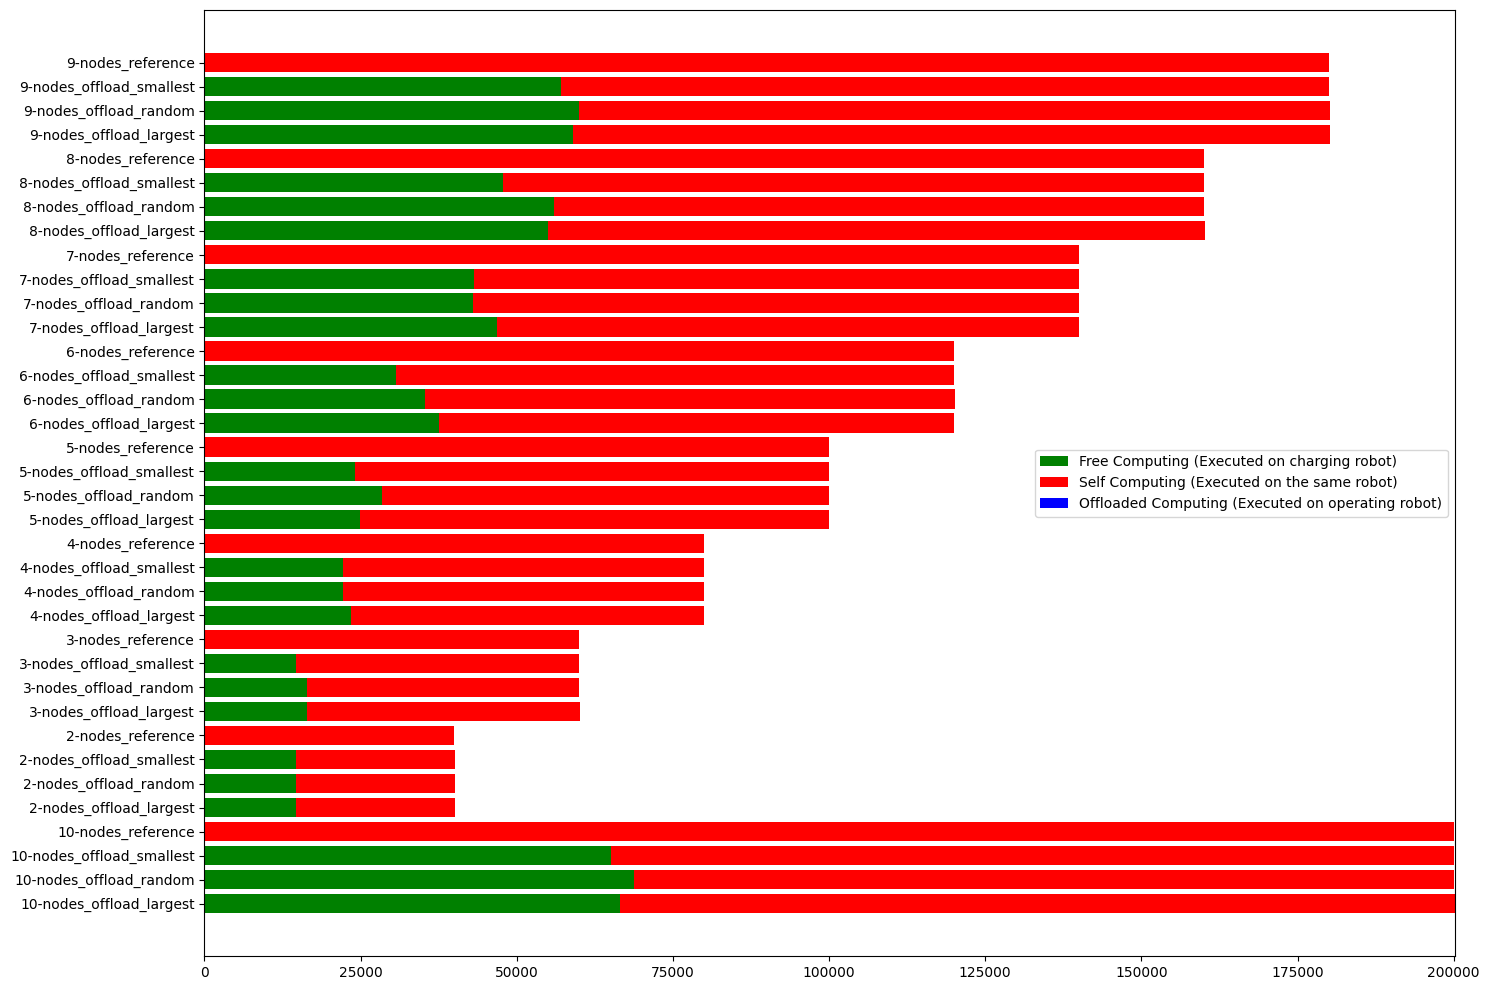

In [7]:
def plot_robot_computing(basedir):
    fig, ax = plt.subplots()
    self_c = []
    free_c = []
    off_c = []
    x = []
    
    for dir in sorted(os.listdir(basedir)):
        dir_path = os.path.join(basedir, dir)
        if not os.path.isdir(dir_path):
            continue
        
        x.append(dir)
        df = pd.read_csv(os.path.join(dir_path, 'simulation_stats.csv'))
        
        # Calculate cumulative free and cost computing
        cum_free = df.filter(like='free_computing').sum().sum()
        cum_self = df.filter(like='self_computing').sum().sum()
        cum_off = df.filter(like='offload_computing').sum().sum()
        
        self_c.append(cum_self)
        free_c.append(cum_free)
        off_c.append(cum_off)
        
    free_c = np.array(free_c)
    self_c = np.array(self_c)
    off_c = np.array(off_c)
        
    # Plotting
    ax.barh(x, free_c, color='g', label='Free Computing (Executed on charging robot)')
    ax.barh(x, self_c, left=free_c, color='r', label='Self Computing (Executed on the same robot)')
    ax.barh(x, off_c, left=free_c+self_c, color='b', label="Offloaded Computing (Executed on operating robot)")

    # Set figure size
    fig.set_figheight(10)
    fig.set_figwidth(15)

    # Add legend
    ax.legend()

    # Adjust layout
    plt.tight_layout()
    plt.show()
    
plot_robot_computing(basedir)


10-nodes_offload_largest
10-nodes_offload_random
10-nodes_offload_smallest
10-nodes_reference
2-nodes_offload_largest
2-nodes_offload_random
2-nodes_offload_smallest
2-nodes_reference
3-nodes_offload_largest
3-nodes_offload_random
3-nodes_offload_smallest
3-nodes_reference
4-nodes_offload_largest
4-nodes_offload_random
4-nodes_offload_smallest
4-nodes_reference
5-nodes_offload_largest
5-nodes_offload_random
5-nodes_offload_smallest
5-nodes_reference
6-nodes_offload_largest
6-nodes_offload_random
6-nodes_offload_smallest
6-nodes_reference
7-nodes_offload_largest
7-nodes_offload_random
7-nodes_offload_smallest
7-nodes_reference
8-nodes_offload_largest
8-nodes_offload_random
8-nodes_offload_smallest
8-nodes_reference
9-nodes_offload_largest
9-nodes_offload_random
9-nodes_offload_smallest
9-nodes_reference


UnboundLocalError: cannot access local variable 'x' where it is not associated with a value

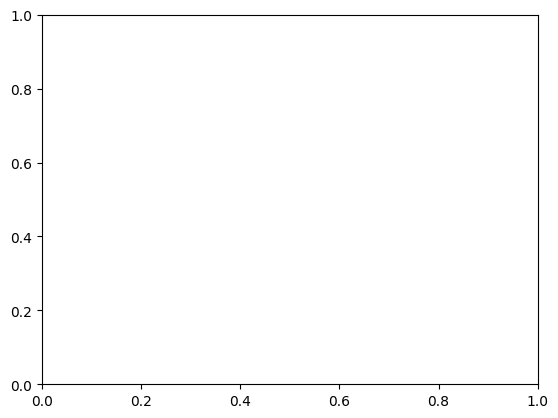

In [17]:
def plot_increase_operation_time(basedir):
    fig, ax = plt.subplots()

    batt_l = []
    opt_l = []
    x_l = []

    for base_dir in sorted(os.listdir(basedir)):
        print(base_dir)
        if "res" not in base_dir:
            continue
        
        dir_path = os.path.join(basedir, base_dir)
        res = {}
        res["reference"] = {}
        res["battery"] = {}
        res["optimized"] = {}
        
        for dir in sorted(os.listdir(dir_path)):
            d_path = os.path.join(dir_path, dir)
            if not os.path.isdir(d_path):
                continue
            
            df = pd.read_csv(os.path.join(d_path, 'simulation_stats.csv'))
            cum = df.filter(like='operation_time').sum().sum()
            n_robot = int(df.filter(like='n_robot').sum().sum())
            
            if "reference" in dir:
                res["reference"][n_robot] = cum
            elif "opt" in dir:
                if n_robot not in res["optimized"] or cum > res["optimized"][n_robot]:
                    res["optimized"][n_robot] = cum
            elif "charging" in dir:
                res["battery"][n_robot] = cum
  
        batt = []
        opt = []
        x = []
        for key in res["reference"]:
            batt.append((res["battery"][key] - res["reference"][key])/res["reference"][key] * 100)
            opt.append((res["optimized"][key] - res["reference"][key])/res["reference"][key] * 100)
            x.append(int(key))

        batt_l.append(batt)
        opt_l.append(opt)
        x_l.append(x)
    
    ax.plot(sorted(x), batt, label="offload on charging devices")
    ax.plot(sorted(x), opt, label="offload on any device")
    ax.legend()
        
plot_increase_operation_time("../res0")